In [1]:
import sys
print("Python:", sys.version)
print("Executable:", sys.executable)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("sklearn:", sklearn.__version__)

Python: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
Executable: C:\Users\1647592\PycharmProjects\Clustering_methods\.venv\Scripts\python.exe
numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8
sklearn: 1.8.0


In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 5)

# Методы кластеризации
## Подготовка признаков

In [6]:
import matplotlib.pyplot as plt

def plot_2d(X2d, labels, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(X2d[:, 0], X2d[:, 1], c=labels, s=8)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

### Импорт датасета

In [7]:
import pandas as pd

df = pd.read_csv("spotify_tracks.csv")
df.shape, df.columns.tolist()[:10]

((50000, 21),
 ['track_id',
  'track_name',
  'artist_name',
  'album_name',
  'release_year',
  'genre',
  'popularity',
  'duration_ms',
  'explicit',
  'danceability'])

### Выбор признаков для кластеризации

In [8]:
features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms", "popularity"
]

X = df[features].dropna()

X.shape, X.head(3)

((50000, 11),
    danceability    energy  loudness  speechiness  acousticness  \
 0      0.427723  1.000000 -4.702460     0.050635      0.239506   
 1      0.448634  0.730911 -7.110031     0.000000      0.044463   
 2      0.707923  0.744997 -7.305120     0.144091      0.118380   
 
    instrumentalness  liveness   valence       tempo  duration_ms  popularity  
 0          0.181395  0.133053  0.431384  141.048735       189042          14  
 1          0.097818  0.435949  0.559135  131.833287       186805          11  
 2          0.000000  0.262254  0.516873  127.132954       121814          23  )

### Масштабирование

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(50000, 11)

### Подготовка и тест визуализации

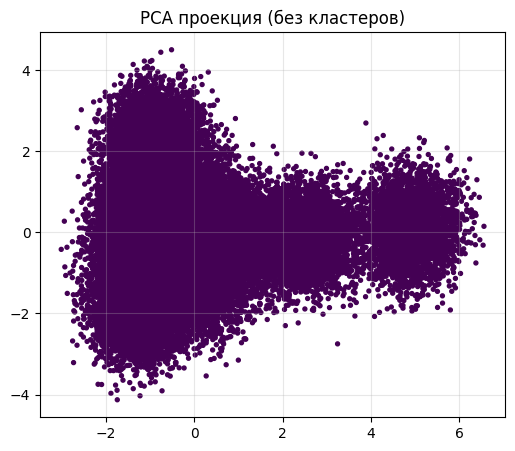

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X2d = pca.fit_transform(X_scaled)

X2d.shape

plot_2d(X2d, labels=[0]*len(X2d), title="PCA проекция (без кластеров)")

### Для ускорения работы методов Spectral и Ward уменьшим выборку

In [11]:
X_sample = X.sample(n=5000, random_state=42)  # можно 2000-8000
X_sample_scaled = scaler.fit_transform(X_sample)

X_sample_2d = PCA(n_components=2, random_state=42).fit_transform(X_sample_scaled)

X_sample.shape

(5000, 11)

## 1) KMeans

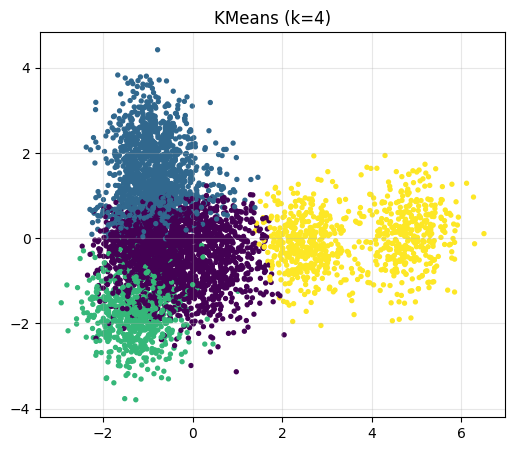

In [19]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

labels_kmeans = kmeans.fit_predict(X_sample_scaled)

plot_2d(X_sample_2d, labels_kmeans, f"KMeans (k={k})")

**KMeans** — метод разбиения данных на K кластеров, основанный на минимизации суммы квадратов расстояний от объектов до центров кластеров (центроидов). 

Алгоритм работает итеративно: 
1) назначает каждому объекту ближайший центроид
2) пересчитывает центроиды как среднее значение признаков объектов в кластере
3) повторяет шаги до стабилизации.
   
Применяется для сегментации объектов (например, группировка треков по аудиохарактеристикам), кластеризации признаков и быстрого первичного анализа структуры данных. Требует заранее задать число кластеров K и чувствителен к масштабу признаков, поэтому перед применением обычно выполняют стандартизацию.

## 2) Ward (AgglomerativeClustering, linkage="ward")

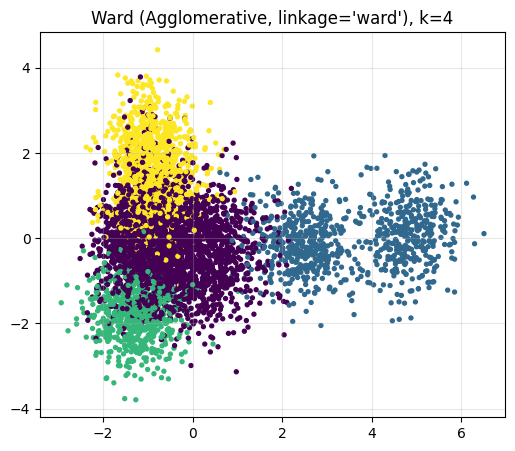

In [22]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

ward = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_ward = ward.fit_predict(X_sample_scaled)

plot_2d(X_sample_2d, labels_ward, "Ward (Agglomerative, linkage='ward'), k=4")

**Ward** — метод, который начинает с того, что каждая точка является отдельным кластером, и затем постепенно объединяет кластеры. При стратегии ward выбирается такое объединение, которое минимально увеличивает внутрикластерную дисперсию (сумму квадратов отклонений). Метод применяют, когда важна интерпретируемость и “иерархичность” разбиения. Хорошо подходит для компактных кластеров, но может быть вычислительно затратным на больших данных, поэтому используется подвыборка.

## 3) DBSCAN

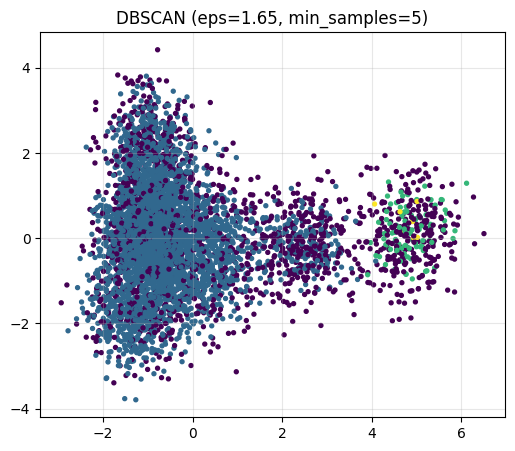

In [44]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

db = DBSCAN(eps=1.65, min_samples=10)
labels_db = db.fit_predict(X_sample_scaled)

plot_2d(X_sample_2d, labels_db, "DBSCAN (eps=1.65, min_samples=5)")

**DBSCAN** выделяет плотные области и помечает редкие точки как шум (-1).

Параметр eps задаёт “радиус соседства”, min_samples — сколько соседей нужно, чтобы точка считалась “ядром”.

Для выбранных данных после стандартизации удаётся получить несколько кластеров и часть шумовых объектов; метод чувствителен к параметрам.

## 4) Spectral Clustering

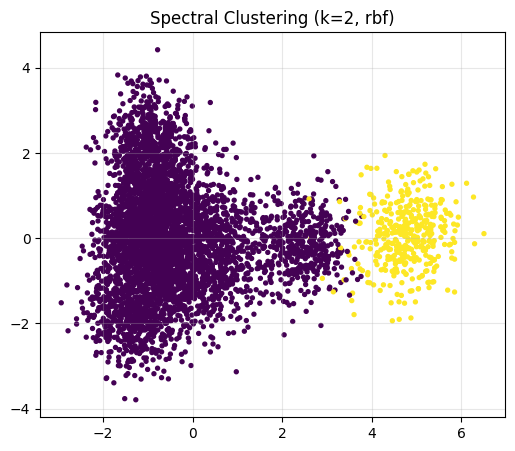

In [49]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import pandas as pd

best_k = 2

spec = SpectralClustering(n_clusters=best_k, affinity="rbf", gamma=1.0, random_state=42)
labels_spec = spec.fit_predict(X_sample_scaled)

plot_2d(X_sample_2d, labels_spec, f"Spectral Clustering (k={best_k}, rbf)")

**Spectral Clustering** строит граф похожести объектов и использует спектральное разложение матрицы Лапласа, после чего выполняет кластеризацию в полученном пространстве. Метод хорошо выявляет сложные структуры и не ограничивается “шарообразными” кластерами. 

## 5) Gaussian Mixture (GMM)

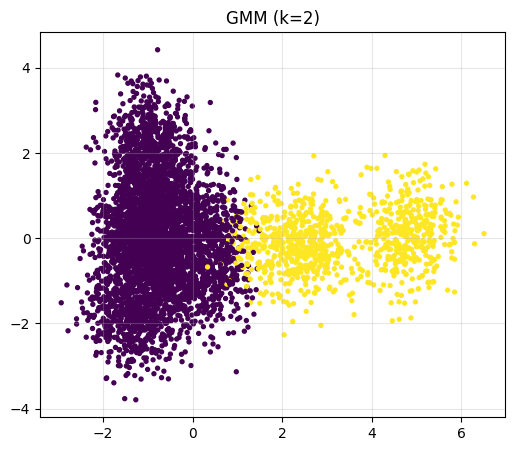

In [52]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pandas as pd

k_gmm = 2
gmm = GaussianMixture(n_components=k_gmm, covariance_type="full", random_state=42)
labels_gmm = gmm.fit_predict(X_sample_scaled)

plot_2d(X_sample_2d, labels_gmm, f"GMM (k={k_gmm})")

**Gaussian Mixture Model** предполагает, что данные описываются смесью нескольких нормальных распределений. Параметры оцениваются EM-алгоритмом, а результатом является не только метка кластера, но и вероятность принадлежности к каждому кластеру. GMM полезен, когда кластеры имеют эллипсоидную форму и требуется “мягкая” кластеризация.

## Выводы и сравнение

### Сводная таблица метрик

In [53]:
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

summary = []

# KMeans (лучшее из твоего подбора среди k>=3 было k=4)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_sample_scaled)
summary.append(("KMeans", "k=4", silhouette_score(X_sample_scaled, labels_km)))

# Ward
from sklearn.cluster import AgglomerativeClustering
ward = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_w = ward.fit_predict(X_sample_scaled)
summary.append(("Ward", "k=4", silhouette_score(X_sample_scaled, labels_w)))

# DBSCAN (silhouette без шума)
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=1.65, min_samples=5)
labels_db = db.fit_predict(X_sample_scaled)
mask = labels_db != -1
if len(set(labels_db[mask])) >= 2:
    sil_db = silhouette_score(X_sample_scaled[mask], labels_db[mask])
else:
    sil_db = np.nan
summary.append(("DBSCAN", "eps=1.65, ms=5 (без шума)", sil_db))

# Spectral
from sklearn.cluster import SpectralClustering
spec = SpectralClustering(n_clusters=2, affinity="rbf", gamma=1.0, random_state=42)
labels_s = spec.fit_predict(X_sample_scaled)
summary.append(("Spectral", "k=2", silhouette_score(X_sample_scaled, labels_s)))

# GMM
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
labels_g = gmm.fit_predict(X_sample_scaled)
summary.append(("GMM", "k=2", silhouette_score(X_sample_scaled, labels_g)))

pd.DataFrame(summary, columns=["Метод", "Параметры", "Silhouette"]).sort_values("Silhouette", ascending=False)

,Метод,Параметры,Silhouette
3,Spectral,k=2,0.359752
4,GMM,k=2,0.292831
0,KMeans,k=4,0.157930
1,Ward,k=4,0.136215
2,DBSCAN,"eps=1.65, ms=5 (без шума)",0.066148


На выбранных данных (11 аудиопризнаков, стандартизация, выборка 5000) большинство методов показывают, что наиболее устойчивое разбиение соответствует 2 крупным группам (максимальный silhouette у Spectral и GMM/KMeans при k=2).

При увеличении числа кластеров качество по silhouette снижается, что указывает на “плавную” структуру данных без чётко отделимых многочисленных групп.

DBSCAN чувствителен к параметрам eps и min_samples: при малом eps почти все объекты становятся шумом, при большом — данные сливаются в один кластер; подобранный компромисс даёт несколько кластеров и выделяет шумовые точки.

Ward и KMeans удобны для компактных кластеров и дают интерпретируемые группы, но требуют заранее задавать число кластеров.

GMM отличается тем, что даёт вероятности принадлежности к кластерам и лучше подходит, если кластеры имеют “эллипсоидную” форму.